In [41]:
import boto3
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
bucket = "dsan6000-pb1100"
prefix = "wikipedia-hourly"

s3 = boto3.client("s3")
paginator = s3.get_paginator("list_objects_v2")

keys = []
for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
    for item in page.get("Contents", []):
        if item["Key"].endswith(".parquet"):
            keys.append(item["Key"])

In [28]:
dfs = []
for key in keys:
    dfs.append(pd.read_parquet(f"s3://{bucket}/{key}"))

hours_df = pd.concat(dfs, ignore_index=True)

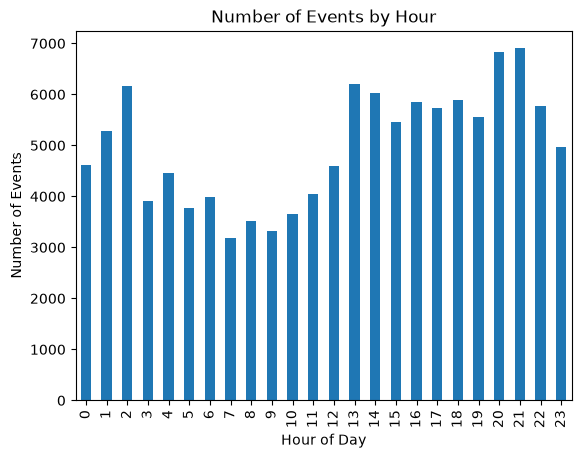

In [47]:
hours_df["datetime"] = pd.to_datetime(hours_df["datetime"])
hours_df["hour"] = hours_df["datetime"].dt.hour

hourly = hours_df.groupby("hour").size()

hourly.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")
plt.title("Number of Events by Hour")
plt.xticks(range(24))

folder = "images"
plt.savefig(f"{folder}/hourly_events.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{folder}/hourly_events.svg", bbox_inches="tight")
plt.show()

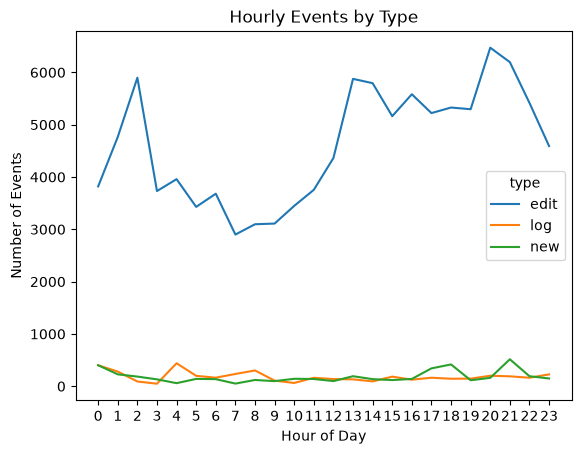

In [49]:
hourly_type = hours_df.groupby(["hour", "type"]).size().reset_index(name="count")

sns.lineplot(
    data=hourly_type,
    x="hour",
    y="count",
    hue="type"
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")
plt.title("Hourly Events by Type")
plt.xticks(range(24))

folder = "images"
plt.savefig(f"{folder}/events-by-type.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{folder}/events-by-type.svg", bbox_inches="tight")
plt.show()